### Ridge & Lasso Regression Model Training

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Load the necesary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ImpactSense_Oct25/data/earthquakes_data_preprocessed.csv')

# Prepare features and target variable
X = df.drop(columns=['risk_score'])
y = df['risk_score']

In [22]:
# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Initialize Ridge Regression Model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [24]:
# Predict on test set
y_pred = ridge_model.predict(X_test)

In [25]:
# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Ridge Regression Mean Squared Error: {mse}")
print(f"Ridge Regression R-squared: {r2}")

Ridge Regression Mean Squared Error: 16.911607503683364
Ridge Regression R-squared: 0.20436265534551534


In [26]:
## Initialize Lasso Regression Model

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

Lasso()

In [27]:
# Predict on test set
y_pred = lasso_model.predict(X_test)

In [28]:
# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Ridge Regression Mean Squared Error: {mse}")
print(f"Ridge Regression R-squared: {r2}")

Ridge Regression Mean Squared Error: 20.961457707295896
Ridge Regression R-squared: 0.013830084059852643


### Task:
- Implement Hyperparameter tuning on both ridge and lasso regression model training and write down your observations about the results.

In [29]:

param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search_ridge.fit(X_train, y_train)

print("Best parameters for Ridge Regression:", grid_search_ridge.best_params_)

Best parameters for Ridge Regression: {'alpha': 10}


In [30]:
best_ridge_model = grid_search_ridge.best_estimator_
y_pred_ridge_tuned = best_ridge_model.predict(X_test)

mse_ridge_tuned = mean_squared_error(y_test, y_pred_ridge_tuned)
r2_ridge_tuned = r2_score(y_test, y_pred_ridge_tuned)

print(f"Tuned Ridge Regression Mean Squared Error: {mse_ridge_tuned}")
print(f"Tuned Ridge Regression R-squared: {r2_ridge_tuned}")

Tuned Ridge Regression Mean Squared Error: 16.911704130775377
Tuned Ridge Regression R-squared: 0.20435810934816434


In [31]:
from sklearn.linear_model import Lasso

param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(Lasso(max_iter=2000), param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search_lasso.fit(X_train, y_train)

print("Best parameters for Lasso Regression:", grid_search_lasso.best_params_)

Best parameters for Lasso Regression: {'alpha': 0.001}


In [32]:
best_lasso_model = grid_search_lasso.best_estimator_
y_pred_lasso_tuned = best_lasso_model.predict(X_test)

mse_lasso_tuned = mean_squared_error(y_test, y_pred_lasso_tuned)
r2_lasso_tuned = r2_score(y_test, y_pred_lasso_tuned)

print(f"Tuned Lasso Regression Mean Squared Error: {mse_lasso_tuned}")
print(f"Tuned Lasso Regression R-squared: {r2_lasso_tuned}")

Tuned Lasso Regression Mean Squared Error: 16.910533012815065
Tuned Lasso Regression R-squared: 0.20441320672338537


### Observations on Hyperparameter Tuning and Model Performance:
**Untuned Models**

Two baseline models were trained without hyperparameter tuning:

*   Untuned Ridge Regression
*   Untuned Lasso Regression

**Predictions were made on the test set**.

Evaluation metrics (Mean Squared Error and R² Score) were calculated to assess initial performance.

These results serve as a reference point for comparison with tuned versions.

**Hyperparameter Tuning (GridSearchCV)**

GridSearchCV was used to find the optimal value of alpha for both Ridge and Lasso.

For each model:

A range of alpha values was supplied: [0.001, 0.01, 0.1, 1, 10, 100]

5-fold cross-validation was performed to evaluate each alpha.


This step helps prevent overfitting and improves generalization by penalizing overly large coefficients.

**Tuned Model Performance**

After tuning:

The Tuned Ridge Regression model and Tuned Lasso Regression model were evaluated on the test set.

Updated MSE and R² scores were recorded.

Comparing untuned vs tuned results reveals whether regularization and tuning improved model performance.

**Key Takeaways**

Ridge Regression (L2 Regularization) shrinks large coefficients, helping stabilize models when features are correlated.

Lasso Regression (L1 Regularization) can shrink some coefficients to zero, effectively performing feature selection.

Hyperparameter tuning is essential because the strength of regularization (alpha) greatly affects model performance.

           Model        MSE        R2
0  Untuned Ridge  16.911608  0.204363
1    Tuned Ridge  16.911704  0.204358
2  Untuned Lasso  20.961458  0.013830
3    Tuned Lasso  16.910533  0.204413


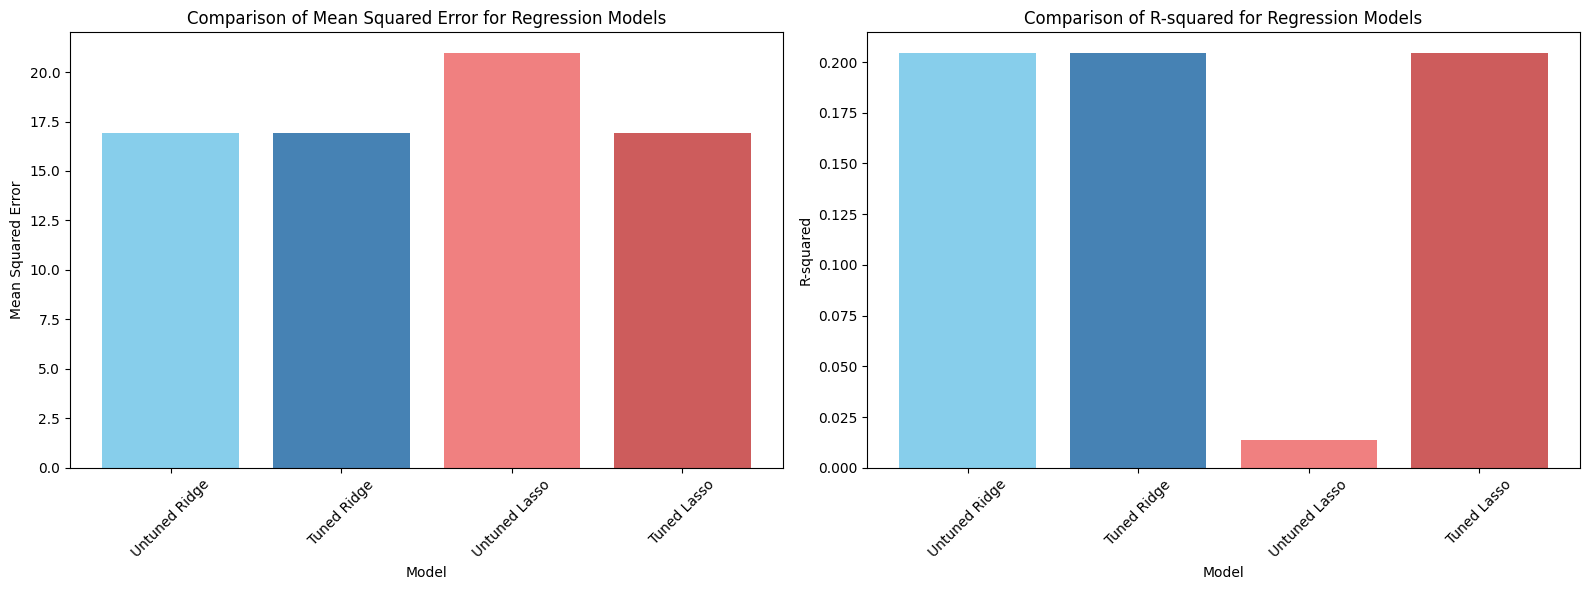

In [33]:
import matplotlib.pyplot as plt

# Gather the performance metrics
untuned_ridge_mse = 16.911607503683364
untuned_ridge_r2 = 0.20436265534551534

# Tuned Ridge
tuned_ridge_mse = mse_ridge_tuned
tuned_ridge_r2 = r2_ridge_tuned

# Untuned Lasso
untuned_lasso_mse = 20.961457707295896
untuned_lasso_r2 = 0.013830084059852643

# Tuned Lasso
tuned_lasso_mse = mse_lasso_tuned
tuned_lasso_r2 = r2_lasso_tuned

# Create a DataFrame to store the results
results_data = {
    'Model': ['Untuned Ridge', 'Tuned Ridge', 'Untuned Lasso', 'Tuned Lasso'],
    'MSE': [untuned_ridge_mse, tuned_ridge_mse, untuned_lasso_mse, tuned_lasso_mse],
    'R2': [untuned_ridge_r2, tuned_ridge_r2, untuned_lasso_r2, tuned_lasso_r2]
}

results_df = pd.DataFrame(results_data)

print(results_df)

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE Plot
axes[0].bar(results_df['Model'], results_df['MSE'], color=['skyblue', 'steelblue', 'lightcoral', 'indianred'])
axes[0].set_title('Comparison of Mean Squared Error for Regression Models')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Mean Squared Error')
axes[0].tick_params(axis='x', rotation=45)

# R-squared Plot
axes[1].bar(results_df['Model'], results_df['R2'], color=['skyblue', 'steelblue', 'lightcoral', 'indianred'])
axes[1].set_title('Comparison of R-squared for Regression Models')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R-squared')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()